# House Price Prediction — Model Building & Evaluation

Trains 7 regressors, runs cross-validation, plots residuals, and tunes the best performer with GridSearchCV.

## 1. Imports & Load Cleaned Data

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from utils import (
    evaluate_model, plot_residuals, plot_pred_vs_actual,
    cross_validate_model, compare_models,
)

sns.set_style('whitegrid')
%matplotlib inline

In [27]:
df = pd.read_csv('data/house_price_cleaned.csv')
print('Shape:', df.shape)
df.head()

Shape: (1460, 268)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,0,0,0,1,0,0,0,1,0
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,0,0,0,0,1,0,0,0,1,0
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,0,0,0,1,0,0,0,1,0
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,0,0,0,1,0,0,0,0,0
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,0,0,0,0,1,0,0,0,1,0


## 2. Train / Test Split & Scaling

In [37]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']
print('Features:', X.shape[1])
print('Target stats:'); print(y.describe().round(2))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Features: 267
Target stats:
count      1460.0
mean     180921.2
std       79442.5
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64
Train: (1168, 267) Test: (292, 267)


## 3. Train 7 Regressors

In [38]:
results = []
models = {}


  Linear Regression
  MAE   : 23927.0377
  RMSE  : 83125.5156
  R2    : 0.0991
  MAPE  : 0.1400


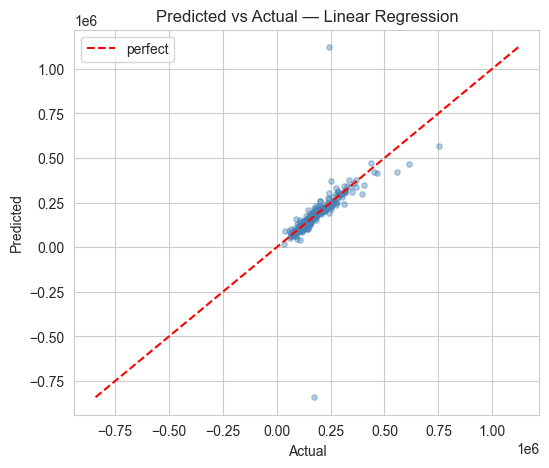

In [39]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
results.append(evaluate_model('Linear Regression', y_test, y_pred))
models['Linear Regression'] = ('scaled', lr)
plot_pred_vs_actual(y_test, y_pred, 'Linear Regression'); plt.show()


  Ridge
  MAE   : 19588.4880
  RMSE  : 35807.3724
  R2    : 0.8328
  MAPE  : 0.1191


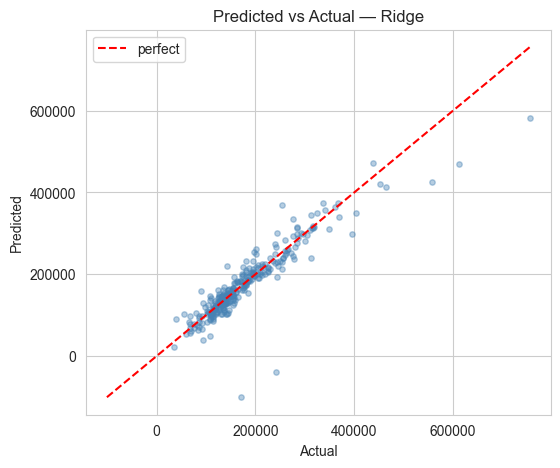

In [40]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
results.append(evaluate_model('Ridge', y_test, y_pred))
models['Ridge'] = ('scaled', ridge)
plot_pred_vs_actual(y_test, y_pred, 'Ridge'); plt.show()


  Lasso
  MAE   : 22336.3253
  RMSE  : 65479.9959
  R2    : 0.4410
  MAPE  : 0.1327


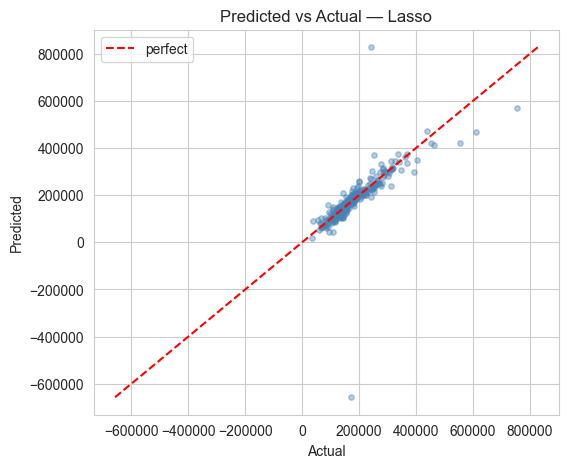

In [41]:
lasso = Lasso(alpha=0.1, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
results.append(evaluate_model('Lasso', y_test, y_pred))
models['Lasso'] = ('scaled', lasso)
plot_pred_vs_actual(y_test, y_pred, 'Lasso'); plt.show()


  Decision Tree
  MAE   : 24766.1351
  RMSE  : 38695.9728
  R2    : 0.8048
  MAPE  : 0.1447


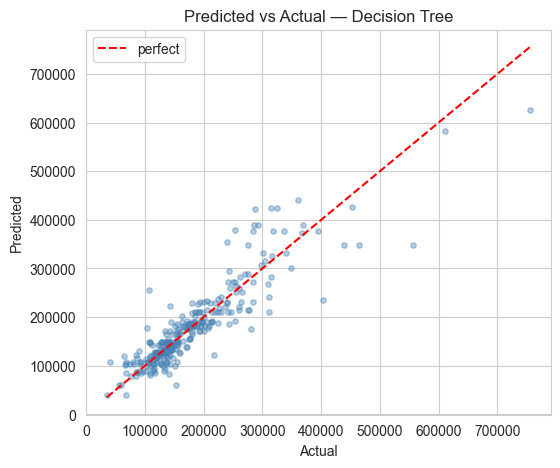

In [42]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
results.append(evaluate_model('Decision Tree', y_test, y_pred))
models['Decision Tree'] = ('raw', dt)
plot_pred_vs_actual(y_test, y_pred, 'Decision Tree'); plt.show()


  Random Forest
  MAE   : 17753.7381
  RMSE  : 29630.6388
  R2    : 0.8855
  MAPE  : 0.1066


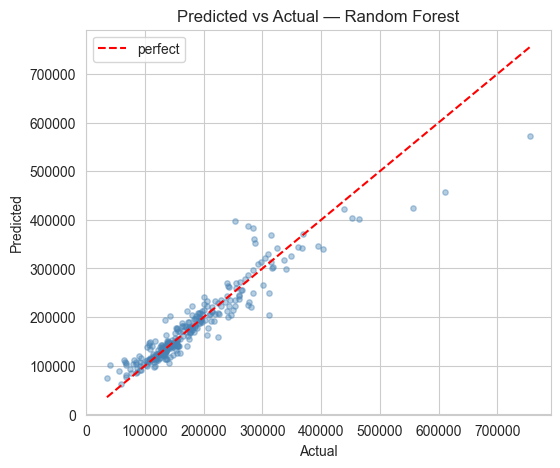

In [43]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
results.append(evaluate_model('Random Forest', y_test, y_pred))
models['Random Forest'] = ('raw', rf)
plot_pred_vs_actual(y_test, y_pred, 'Random Forest'); plt.show()

## 4. Feature Importance — Tree Models


  Gradient Boosting
  MAE   : 16799.7073
  RMSE  : 27126.4231
  R2    : 0.9041
  MAPE  : 0.1002


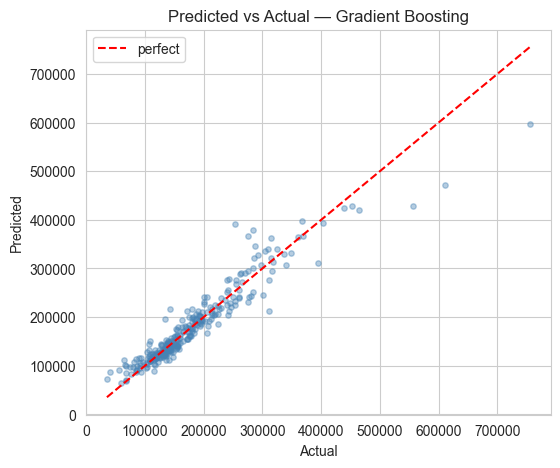


  K-Nearest Neighbors
  MAE   : 24804.0199
  RMSE  : 42989.9066
  R2    : 0.7591
  MAPE  : 0.1537


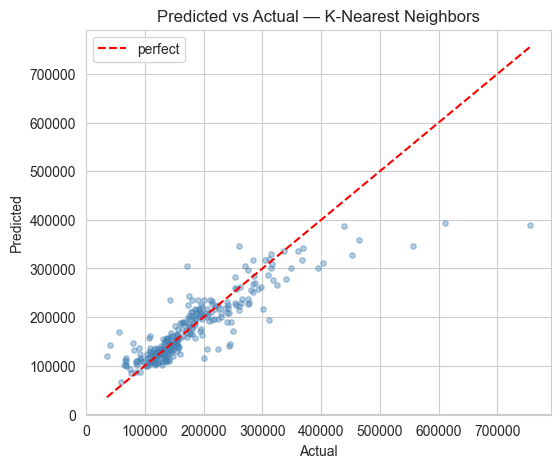

In [44]:
# Train Gradient Boosting Regressor
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)
results.append(evaluate_model('Gradient Boosting', y_test, y_pred))
models['Gradient Boosting'] = ('raw', gb)
plot_pred_vs_actual(y_test, y_pred, 'Gradient Boosting')
plt.show()

# Train K-Nearest Neighbors (requires scaled data)
knn = KNeighborsRegressor()
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
results.append(evaluate_model('K-Nearest Neighbors', y_test, y_pred))
models['K-Nearest Neighbors'] = ('scaled', knn)
plot_pred_vs_actual(y_test, y_pred, 'K-Nearest Neighbors')
plt.show()

## 5. Hyperparameter Tuning — Best Performer

In [ ]:
param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
}
gb_tuned = GradientBoostingRegressor(random_state=42)
grid = GridSearchCV(gb_tuned, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
print('Best params:', grid.best_params_)
print('Best CV R²:', round(grid.best_score_, 4))
best = grid.best_estimator_
y_pred = best.predict(X_test)
tuned_metrics = evaluate_model('Gradient Boosting (Tuned)', y_test, y_pred)
results.append(tuned_metrics)
plot_residuals(y_test, y_pred, 'Gradient Boosting (Tuned)'); plt.show()

## 10. Sample Prediction

In [36]:
sample = X_test.iloc[:5].copy()
preds = best.predict(sample)
out = pd.DataFrame({'Predicted': preds.round(2), 'Actual': y_test.iloc[:5].values.round(2)})
out['AbsError'] = (out['Predicted'] - out['Actual']).abs().round(2)
out

NameError: name 'best' is not defined

## 11. Final Summary

In [ ]:
final = compare_models(results)
final